# EDA — Genius annotations corpus

Explore the raw annotation corpus before chunking and embedding, and turn the numbers
into concrete decisions for the retrieval pipeline. See **Conclusions** at the bottom.

In [1]:
import glob
from pathlib import Path

import pandas as pd

pd.set_option("display.max_colwidth", 80)
RAW = Path("../data/raw")
print("files:", [Path(f).name for f in glob.glob(str(RAW / "*.jsonl"))])

files: ['yeat.jsonl', 'kai_angel.jsonl', 'justin_bieber.jsonl', 'travis_scott.jsonl', 'adéla.jsonl', 'don_toliver.jsonl', 'kendrick_lamar.jsonl', 'oxxxymiron.jsonl', 'the_weeknd.jsonl']


## 1. Load: JSONL files into one DataFrame (one row per song)

In [2]:
frames = [pd.read_json(p, lines=True) for p in glob.glob(str(RAW / "*.jsonl"))]
df_songs = pd.concat(frames, ignore_index=True)
df_songs.shape

(45, 5)

## 2. Explode annotations (one row per annotation)

Each song holds a list of annotations. `explode` turns the list into rows, then we
extract `fragment` and `text` into their own columns. Songs with no annotations
become NaN after explode and are dropped.

In [3]:
df_ann = df_songs.explode("annotations", ignore_index=True)
df_ann = df_ann.dropna(subset=["annotations"])
df_ann["fragment"] = df_ann["annotations"].apply(lambda a: a.get("fragment"))
df_ann["text"] = df_ann["annotations"].apply(lambda a: a.get("text"))
df_ann = df_ann[["artists", "title", "album", "fragment", "text"]]
df_ann.shape

(1204, 5)

## 3. Annotations per track — imbalance

In [4]:
per_track = df_ann.groupby("title").size()
print("tracks:", per_track.shape[0])
per_track.describe()

tracks: 44


count     44.000000
mean      27.363636
std       39.143202
min        3.000000
25%        9.000000
50%       16.500000
75%       25.000000
max      242.000000
dtype: float64

In [5]:
per_track.sort_values(ascending=False).head(10)

title
13/08/17: Oxxxymiron vs. Слава КПСС    242
euphoria                                91
m.A.A.d city                            81
12/04/15: Oxxxymiron vs. Johnyboy       77
Not Like Us                             61
«Где нас нет» (”On the Other Side”)     48
SICKO MODE                              48
Fuckin’ Problems                        42
FIELD TRIP                              36
Flawlëss                                29
dtype: int64

## 4. Annotation text length — is chunking needed?

Rough token estimate: `chars / 3` (a compromise between Latin ~/4 and Cyrillic ~/2).

In [6]:
df_ann["chars"] = df_ann["text"].str.len()
df_ann["token_est"] = (df_ann["chars"] / 3).round()

for thr in (150, 300, 500):
    print(f"tokens > {thr}: {round((df_ann['token_est'] > thr).mean() * 100, 1)} %")

df_ann[["chars", "token_est"]].describe(percentiles=[.5, .9, .95, .99])

tokens > 150: 38.6 %
tokens > 300: 11.5 %
tokens > 500: 3.1 %


,chars,token_est
count,1204.000000,1204.000000
mean,479.754983,159.921927
std,405.165066,135.051632
min,9.000000,3.000000
50%,372.500000,124.000000
90%,949.600000,316.400000
95%,1270.250000,423.700000
99%,2088.340000,695.790000
max,3329.000000,1110.000000


<Axes: title={'center': 'Annotation length (est. tokens)'}, ylabel='Frequency'>

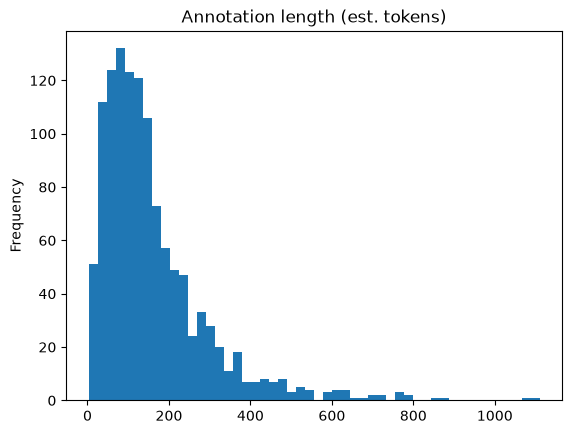

In [7]:
df_ann["token_est"].plot.hist(bins=50, title="Annotation length (est. tokens)")

## 5. Fragment length (the query anchor)

In [8]:
df_ann["fragment"].str.len().describe(percentiles=[.5, .9, .99])

count    1204.000000
mean       72.038206
std        66.249800
min         3.000000
50%        54.000000
90%       137.000000
99%       331.670000
max       767.000000
Name: fragment, dtype: float64

## 6. Noise: empties and duplicates

In [9]:
print("near-empty (<10 chars):", int((df_ann["text"].str.len() < 10).sum()))
print("duplicate texts:", int(df_ann["text"].duplicated().sum()))

near-empty (<10 chars): 1
duplicate texts: 16


## 7. Language split (ru vs en)

In [10]:
def cyrillic_ratio(s: str) -> float:
    """Share of Cyrillic among alphabetic characters (0..1)."""
    letters = [ch for ch in s if ch.isalpha()]
    if not letters:
        return 0.0
    cyr = sum("а" <= ch.lower() <= "я" or ch.lower() == "ё" for ch in letters)
    return cyr / len(letters)


df_ann["lang"] = df_ann["text"].apply(lambda t: "ru" if cyrillic_ratio(t) > 0.5 else "en")
df_ann["lang"].value_counts()

lang
en    774
ru    430
Name: count, dtype: int64

## Conclusions

Corpus: 9 artists, 45 tracks, 1204 annotations (en 774 / ru 430).

- **Chunking** — median 124 est. tokens, 88.5% under 300, but a tail up to ~1110 (3.1% over 500);
  the e5 embedder truncates around 512 tokens.
  → treat each annotation as one chunk for ~88% of data; split only annotations longer than ~350 tokens,
  otherwise the tail gets silently truncated by the embedder.

- **Imbalance** — annotations per track: median 16.5, max 242, std > mean (right-skewed; the two Oxxxymiron
  battles dominate).
  → report retrieval metrics per track / per language, not as a single corpus average, so heavy tracks
  don't mask poor recall on the rest.

- **Cleaning** — 16 duplicate texts and 1 near-empty annotation; fragments are short (median 54 chars) with
  a single 767-char outlier.
  → deduplicate by text and drop empties (~17 rows) before indexing.

- **Language** — en 774 / ru 430 (64% / 36%), both significant.
  → a multilingual embedder is required; evaluate ru and en separately so a language skew doesn't hide
  weakness in one of them.